# Titanic: Machine Learning from Disaster
### Predict survival on the Titanic
- Defining the problem statement
- Collecting the data
- Exploratory data analysis(EDA)
- Feature engineering
- Modelling
- Testing

## 1_1.Defining the problem statement
Complete the analysis of what sorts of people were likely to survive.
In particular, we ask you to apply the tools of machine learning to predict which passengers survived the Titanic tragedy.

In [336]:
from IPython.display import Image
Image(url= "https://static1.squarespace.com/static/5006453fe4b09ef2252ba068/5095eabce4b06cb305058603/5095eabce4b02d37bef4c24c/1352002236895/100_anniversary_titanic_sinking_by_esai8mellows-d4xbme8.jpg")

## 1_2.Collecting the data(데이터 수집)

In [337]:
import pandas as pd

train = pd.read_csv('../data/train.csv') # 891
test = pd.read_csv('../data/test.csv') # 418


## 1_3.Exploratory data analysis(탐색적 데이터 분석)

Printing first 5 rows of the train dataset

In [338]:


# Printing first 5 rows of the train dataset
train.head(100)

# SibSp 형제 자매

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",male,NaN,0,0,374910,8.0500,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
97,98,1,1,"Greenfield, Mr. William Bertram",male,23.0,0,1,PC 17759,63.3583,D10 D12,C
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,34.0,0,1,231919,23.0000,NaN,S


### Data dictionary
- Survived(생존여부) : 0=No, 1=Yes
- Pclass(객실등급) : Ticket class  1=1st  2=2st 3=3st
- sibsp(형제/자매 및 배우자) :  soblingd / spouses ablout the Titanic
- parch(부모/자녀) :  parents / children ablout the Titanic
- ticket(티켓 번호) : Ticket number
- cabin(객실 번호) : Cabin number
- embarked(승선 항구) : Port of Embarkation C=Cherbourg, Q=Queenstown, S=Southampton

In [339]:
test.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


Total rows and columns

We can see that there are 891 rows and 12 columns in our training dataset.

In [340]:
train.shape

(891, 12)

In [341]:
test.shape

(418, 11)

In [342]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [343]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


## We can see that Age value is missing for many rows.

## Out of 891 rows, the Age value is present only 741

In [344]:
test.isnull().sum()

# Data dictionary   
# - Survived(생존여부) : 0=No, 1=Yes
# - Pclass(객실등급) : Ticket class  1=1st  2=2st 3=3st
# - sibsp(형제/자매 및 배우자) :  soblingd / spouses ablout the Titanic
# - parch(부모/자녀) :  parents / children ablout the Titanic
# - ticket(티켓 번호) : Ticket number
# - cabin(객실 번호) : Cabin number
# - embarked(승선 항구) : Port of Embarkation C=Cherbourg, Q=Queenstown, S=Southampton

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [345]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set() 

# Bar Chart for Categorical Features

* Pclass
* Sex
* SibSp
* Parch
* Embarked
* Cabin

In [346]:
def bar_chart(feature):
    survived=train[train['Survived']==1][feature].value_counts()
    dead=train[train['Survived']==0][feature].value_counts()
    df=pd.DataFrame([survived, dead])
    df.index=(['Survived','Dead'])
    df.plot(kind='bar', stacked=True, figsize=(10,5))

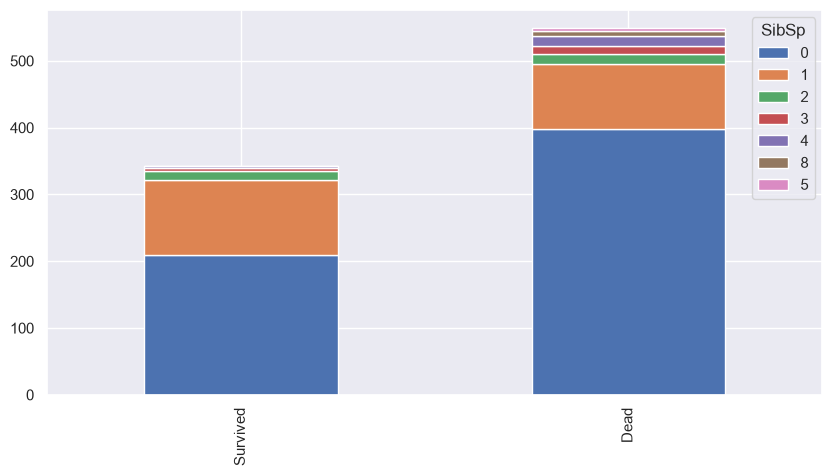

In [347]:
bar_chart('SibSp')

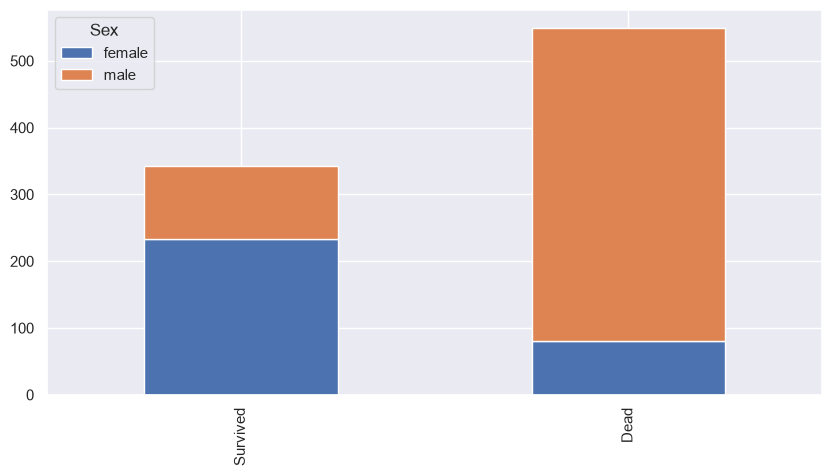

In [348]:
bar_chart('Sex')

# 3.Feature engineering

Feature engineering is the process of using domain knowledge of the data to create features (feature vectors) that make machine learning algorithms work.

feature vector is an n-dimensional vector of numerical features that represent some object. Many algorithms in machine learning require a numerical representation of objects, since such representations facilitate processing and statistical analysis.

## 3-1. how titanic sank?

sank from the bow of the ship where third class rooms located conclusion, Pclass is key feature for classifier

In [349]:
Image(url= "https://static1.squarespace.com/static/5006453fe4b09ef2252ba068/t/5090b249e4b047ba54dfd258/1351660113175/TItanic-Survival-Infographic.jpg?format=1500w")

## 3-2 Name

In [350]:
train_test_data=[train, test] # train, test data combining
# expand=False: Series 형태로 변환
for dataset in train_test_data:
    dataset['Title']=dataset['Name'].str.extract('([A-Za-z]+)\.',expand=False)    
    # extract('([A-Za-z]+)\.: 영어로 시작하고 . 이 찍혀있는것 가져오기(MR. Miss. MRs.) 성별, 결혼유무에 따른 사망 상관관계 확인 목적

<>:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\soldesk\AppData\Local\Temp\ipykernel_17892\1751997189.py:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  dataset['Title']=dataset['Name'].str.extract('([A-Za-z]+)\.',expand=False)


In [351]:
train['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [352]:
test['Title'].value_counts()

Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

In [353]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  Title        891 non-null    str    
dtypes: float64(2), int64(5), str(6)
memory usage: 90.6 KB


In [354]:
# 1, 2, 3과 매핑
title_mapping = {
    "Mr": 0, "Miss": 1, "Mrs": 2, 
    "Master": 3, "Dr": 3, "Rev": 3, "Col": 3, "Major": 3, "Mlle": 3, "Countess": 3,
    "Ms": 3, "Lady": 3, "Jonkheer": 3, "Don": 3, "Dona": 3, "Mme": 3, "Capt": 3, "Sir": 3
}

# 전처리된 title 컬럼을 매핑하여 생성
for dataset in train_test_data:
    dataset['Title'] = dataset['Title'].map(title_mapping)

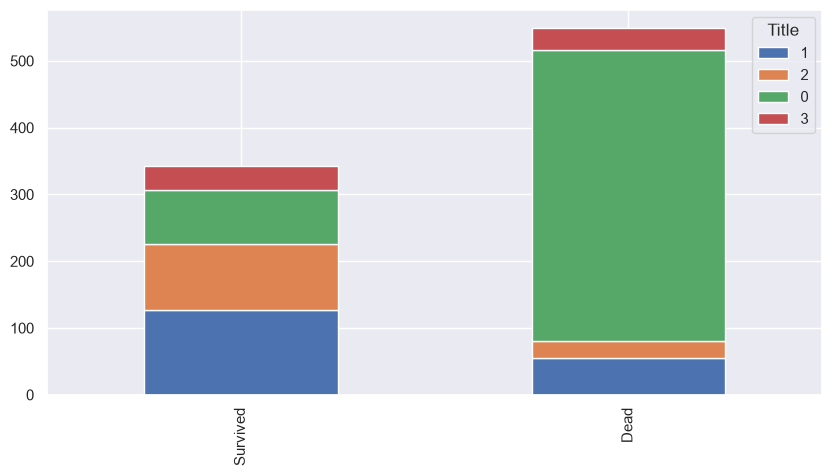

In [355]:
bar_chart('Title')

In [356]:
# delete feature from dataset  (#이름 자체는 중요하지 않아서 이름 삭제)
train.drop('Name', axis=1, inplace=True)
test.drop('Name', axis=1, inplace=True)

In [357]:
train.head()


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S,0


In [358]:
test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,892,3,male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,female,47.0,1,0,363272,7.0000,NaN,S,2
2,894,2,male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,female,22.0,1,1,3101298,12.2875,NaN,S,2


## 3-3 Sex

- male:0, female : 1

In [359]:
# Sex를 이진화하는 전처리
sex_mapping = {"male":0, "female" : 1}
for dataset in train_test_data:
    dataset['Sex']=dataset['Sex'].map(sex_mapping)

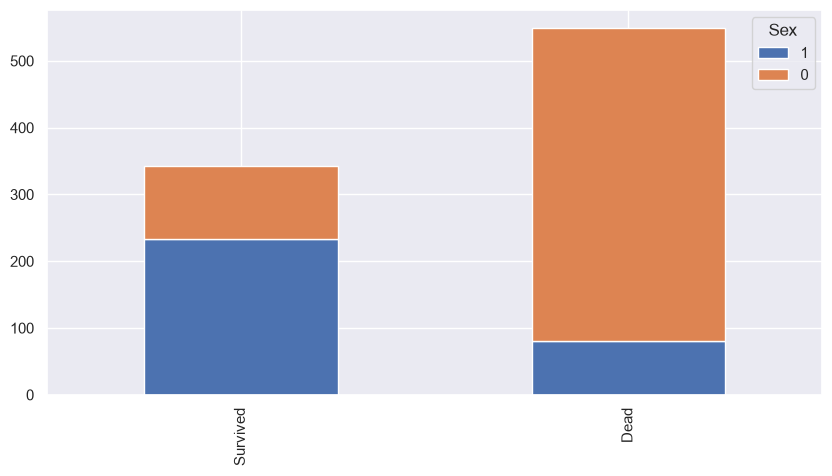

In [360]:
bar_chart('Sex')

In [361]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,1,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,1,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,0,35.0,0,0,373450,8.0500,NaN,S,0


# 4.3 Age

- some age is mission
- Let's use Title's median age for missing Age
- feature scaling

In [362]:
# Age값의 Null 처리 -> 성별별 나이의 중간값을 결측치값에 대입
train["Age"] = train["Age"].fillna(train.groupby("Title")["Age"].transform("median"))
test["Age"] = test["Age"].fillna(test.groupby("Title")["Age"].transform("median"))

In [363]:
train.head(30)
train.groupby("Title")["Age"].transform("median")

0      30.0
1      35.0
2      21.0
3      35.0
4      30.0
       ... 
886     9.0
887    21.0
888    21.0
889    30.0
890    30.0
Name: Age, Length: 891, dtype: float64

In [364]:
train.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Title            0
dtype: int64

In [365]:
test.isnull().sum()

PassengerId      0
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
Title            0
dtype: int64

c:\source\pythonsource\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
c:\source\pythonsource\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


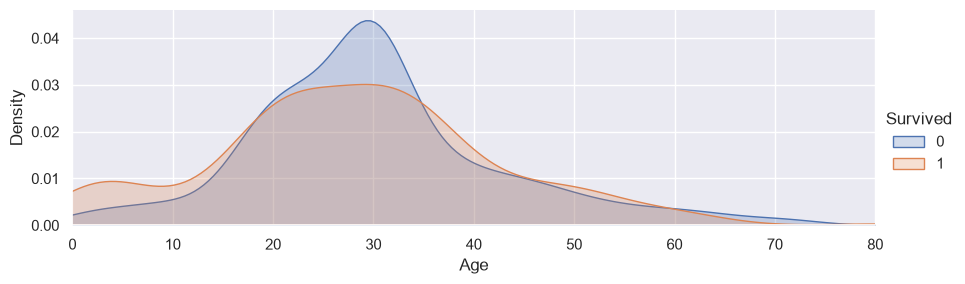

In [366]:
# FacetGrid 객체 생성(생존(1)/사망(0)), aspect=4: 가로 세로 비율
facet = sns.FacetGrid(train, hue="Survived", aspect=3)    # FacetGrid : 차트가 겹치게 나오게 하는 것
facet.map(sns.kdeplot, 'Age', shade=True)  # sns.kdeplot: 곡선 그래프 / shade=True: 곡선아래 색상채움
facet.set(xlim=(0, train['Age'].max()))  # x축 범위를 0 ~ 최대나이
facet.add_legend()
plt.show()

c:\source\pythonsource\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
c:\source\pythonsource\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


(20.0, 40.0)

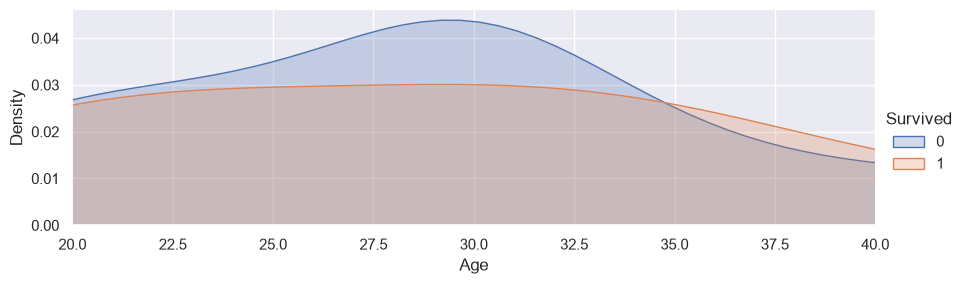

In [367]:
facet = sns.FacetGrid(train, hue="Survived", aspect=3)   
facet.map(sns.kdeplot, 'Age', shade=True)  
facet.set(xlim=(0, train['Age'].max())) 
facet.add_legend()
plt.xlim(0,20)    # 0~20살까지 잘라서 보기
plt.xlim(20,40)   # 20~40살까지

In [368]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    str    
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    str    
 10  Embarked     889 non-null    str    
 11  Title        891 non-null    int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 83.7 KB


train.info()

# Binning

- feature vector map:
- child : 0
- young : 1
- adult : 2
- mid-age : 3
- senior : 4

In [369]:
for dataset in train_test_data:
  dataset.loc[dataset['Age'] <= 16, 'Age']=0
  dataset.loc[(dataset['Age'] > 16) & (dataset['Age'] <=26), 'Age']=1
  dataset.loc[(dataset['Age'] > 26) & (dataset['Age'] <= 36), 'Age']=2
  dataset.loc[(dataset['Age'] > 36) & (dataset['Age'] <= 62), 'Age']=3
  dataset.loc[(dataset['Age'] > 62),  'Age']=4

In [370]:
train.head(20)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,1.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,1,3.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,1,1.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,1,2.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,0,2.0,0,0,373450,8.0500,NaN,S,0
5,6,0,3,0,2.0,0,0,330877,8.4583,NaN,Q,0
6,7,0,1,0,3.0,0,0,17463,51.8625,E46,S,0
7,8,0,3,0,0.0,3,1,349909,21.0750,NaN,S,3
8,9,1,3,1,2.0,0,2,347742,11.1333,NaN,S,2
9,10,1,2,1,0.0,1,0,237736,30.0708,NaN,C,2


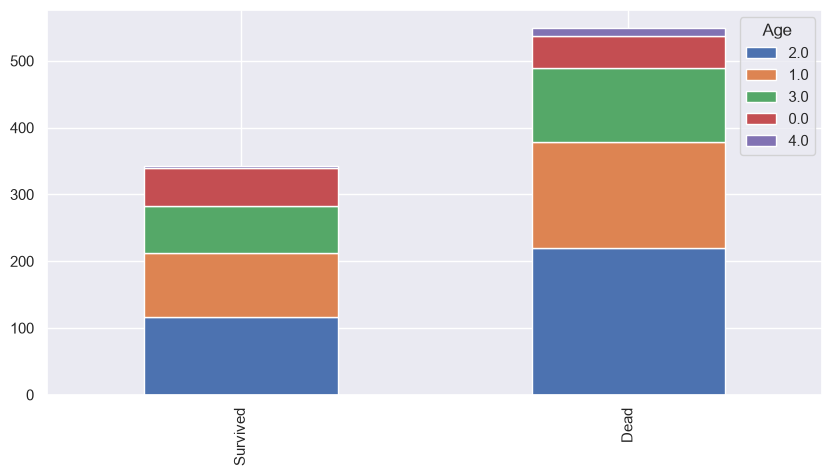

In [371]:
bar_chart('Age')

#### 4-4.Embarked 의 정보가 없으면 S로 대체
- S = Southampton(영국) 주로 3등석
- C = Cherbourg(프랑스) 주로 부유층
- Q = Queenstown(아일랜드) 승객 수 적음

In [372]:
# null 값 전처리
for dataset in train_test_data:
    dataset['Embarked']=dataset['Embarked'].fillna('S')    #null 값을 S로 대체
    
train.head(20)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,1.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,1,3.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,1,1.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,1,2.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,0,2.0,0,0,373450,8.0500,NaN,S,0
5,6,0,3,0,2.0,0,0,330877,8.4583,NaN,Q,0
6,7,0,1,0,3.0,0,0,17463,51.8625,E46,S,0
7,8,0,3,0,0.0,3,1,349909,21.0750,NaN,S,3
8,9,1,3,1,2.0,0,2,347742,11.1333,NaN,S,2
9,10,1,2,1,0.0,1,0,237736,30.0708,NaN,C,2


In [373]:
embarked_mapping={"S":0, "C":1, "Q":2}
for dataset in train_test_data:
    dataset['Embarked'] = dataset['Embarked'].map(embarked_mapping)

In [374]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,1.0,1,0,A/5 21171,7.2500,NaN,0,0
1,2,1,1,1,3.0,1,0,PC 17599,71.2833,C85,1,2
2,3,1,3,1,1.0,0,0,STON/O2. 3101282,7.9250,NaN,0,1
3,4,1,1,1,2.0,1,0,113803,53.1000,C123,0,2
4,5,0,3,0,2.0,0,0,373450,8.0500,NaN,0,0


In [375]:
test.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,892,3,0,2.0,0,0,330911,7.8292,NaN,2,0
1,893,3,1,3.0,1,0,363272,7.0000,NaN,0,2
2,894,2,0,3.0,0,0,240276,9.6875,NaN,2,0
3,895,3,0,2.0,0,0,315154,8.6625,NaN,0,0
4,896,3,1,1.0,1,1,3101298,12.2875,NaN,0,2


## 4-5. Fare

In [376]:
# Pclass의 그룹별 중간값을 Fare의 nan값에 대체
train['Fare']=train['Fare'].fillna(train.groupby("Pclass")["Fare"].transform("median"), inplace=True)
test['Fare']=test['Fare'].fillna(test.groupby("Pclass")["Fare"].transform("median"), inplace=True)

C:\Users\soldesk\AppData\Local\Temp\ipykernel_17892\2574068588.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train['Fare']=train['Fare'].fillna(train.groupby("Pclass")["Fare"].transform("median"), inplace=True)
C:\Users\soldesk\AppData\Local\Temp\ipykernel_17892\2574068588.py:3: ChainedAssignmentError: A value is being set on a

In [377]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    int64  
 3   Age          418 non-null    float64
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Ticket       418 non-null    str    
 7   Fare         418 non-null    float64
 8   Cabin        91 non-null     str    
 9   Embarked     418 non-null    int64  
 10  Title        418 non-null    int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 36.1 KB


c:\source\pythonsource\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
c:\source\pythonsource\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


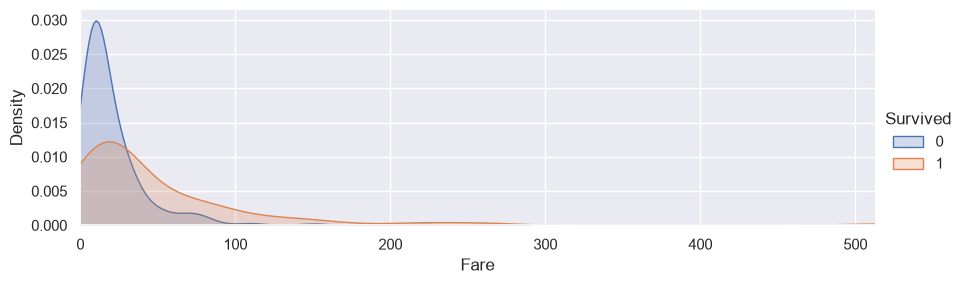

In [378]:
# FacetGrid 객체 생성(생존(1)/사망(0)), aspect=3: 가로 세로 비율
facet = sns.FacetGrid(train, hue="Survived", aspect=3)    # FacetGrid : 차트가 겹치게 나오게 하는 것
facet.map(sns.kdeplot, 'Fare', shade=True)  # sns.kdeplot: 곡선 그래프 / shade=True: 곡선아래 색상채움
facet.set(xlim=(0, train['Fare'].max()))  # x축 범위를 0 ~ 최대나이
facet.add_legend()
plt.show()

c:\source\pythonsource\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
c:\source\pythonsource\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


(0.5, 512.3292)

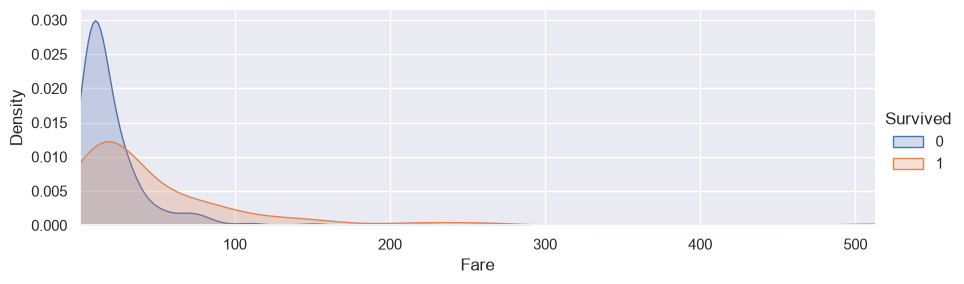

In [379]:
# FacetGrid 객체 생성(생존(1)/사망(0)), aspect=3: 가로 세로 비율
facet = sns.FacetGrid(train, hue="Survived", aspect=3)    # FacetGrid : 차트가 겹치게 나오게 하는 것
facet.map(sns.kdeplot, 'Fare', shade=True)  # sns.kdeplot: 곡선 그래프 / shade=True: 곡선아래 색상채움
facet.set(xlim=(0, train['Fare'].max()))  # x축 범위를 0 ~ 최대나이
facet.add_legend()
plt.xlim(0.50)

# Binning

In [380]:
for dataset in train_test_data:
  dataset.loc[dataset['Fare'] <= 17, 'Fare']=0
  dataset.loc[(dataset['Fare'] > 17) & (dataset['Fare'] <=30), 'Fare']=1
  dataset.loc[(dataset['Fare'] > 30) & (dataset['Fare'] <= 100), 'Fare']=2
  dataset.loc[dataset['Fare'] > 100, 'Fare']=3

In [381]:
train.head(50)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,1.0,1,0,A/5 21171,0.0,NaN,0,0
1,2,1,1,1,3.0,1,0,PC 17599,2.0,C85,1,2
2,3,1,3,1,1.0,0,0,STON/O2. 3101282,0.0,NaN,0,1
3,4,1,1,1,2.0,1,0,113803,2.0,C123,0,2
4,5,0,3,0,2.0,0,0,373450,0.0,NaN,0,0
5,6,0,3,0,2.0,0,0,330877,0.0,NaN,2,0
6,7,0,1,0,3.0,0,0,17463,2.0,E46,0,0
7,8,0,3,0,0.0,3,1,349909,1.0,NaN,0,3
8,9,1,3,1,2.0,0,2,347742,0.0,NaN,0,2
9,10,1,2,1,0.0,1,0,237736,2.0,NaN,1,2


# 4-6 Cabin(방)

In [382]:
train.Cabin.value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [383]:
# 첫 글자만 추출하는 전처리 작업
for dataset in train_test_data:
    dataset['Cabin']=dataset['Cabin'].str[:1]

<Axes: >

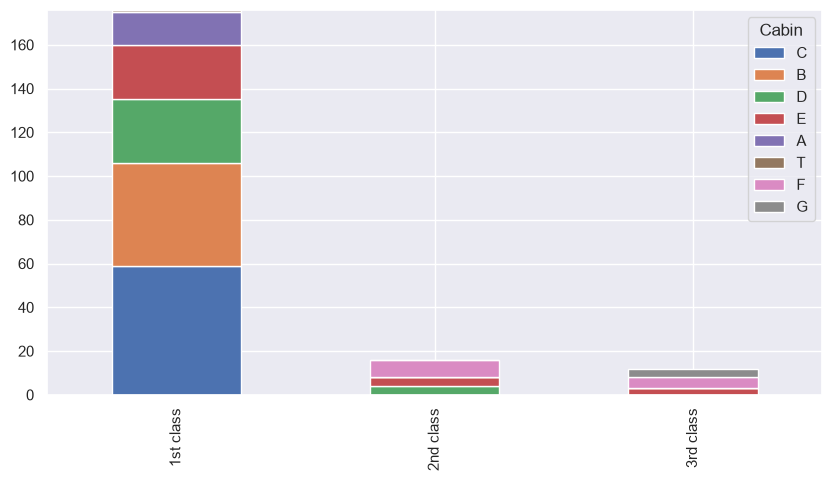

In [384]:
# 1등석은 cabin정보가 많고 3등석은 거의 없음
Pclass1=train[train['Pclass']==1]['Cabin'].value_counts()
Pclass2=train[train['Pclass']==2]['Cabin'].value_counts()
Pclass3=train[train['Pclass']==3]['Cabin'].value_counts()
df=pd.DataFrame([Pclass1,Pclass2,Pclass3])
df.index=['1st class', '2nd class', '3rd class']
df.plot(kind='bar',stacked=True, figsize=(10,5))


In [385]:
# Cabin의 알파벳을 위치/계층적 의미를 고려하여 숫자 값으로 매핑
# 예: A는 고급 구역, G나 T는 하위 구역으로 볼 수 있음. T는 드문 케이스이지만 생존과의 관련성 분석에 유용할 수 있음
cabin_mapping = {"A": 0, "B": 0.4, "C": 0.8, "D": 1.2, "E": 1.6, "F": 2, "G": 2.4, "T": 2.8}
for dataset in train_test_data:
  dataset['Cabin']=dataset['Cabin'].map(cabin_mapping)

In [386]:
# 결측치값 대체
train['Cabin'] = train['Cabin'].fillna(train.groupby("Pclass")["Cabin"].transform("median"))
test["Cabin"] = test["Cabin"].fillna(test.groupby("Pclass")["Cabin"].transform("median"))

In [387]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,0,1.0,1,0,A/5 21171,0.0,2.0,0,0
1,2,1,1,1,3.0,1,0,PC 17599,2.0,0.8,1,2
2,3,1,3,1,1.0,0,0,STON/O2. 3101282,0.0,2.0,0,1
3,4,1,1,1,2.0,1,0,113803,2.0,0.8,0,2
4,5,0,3,0,2.0,0,0,373450,0.0,2.0,0,0


In [388]:
# 형제+부모+본인의 수를 합쳐서 하나의 FamilySize 변수로 생성
# 혼자 탄 사람(1) vs 가족과 함께 탄 사람의 생존률이 차이를 보임
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1



c:\source\pythonsource\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
c:\source\pythonsource\.venv\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


(0.0, 11.0)

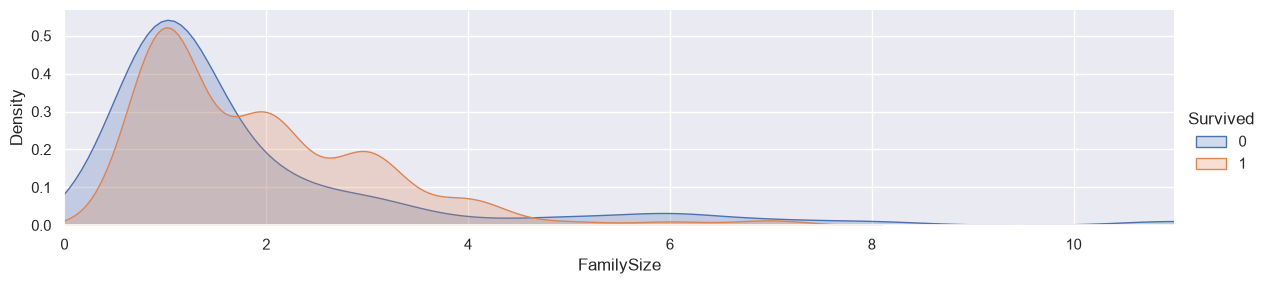

In [389]:
facet = sns.FacetGrid(train, hue="Survived", aspect=4)
facet.map(sns.kdeplot, 'FamilySize', shade=True)
facet.set(xlim=(0, train['FamilySize'].max()))
facet.add_legend()
plt.xlim(0)

In [390]:
# 이미 벡터값이여서 스케일링 되어 반환되지만 숫자에 차이가 있음
# 일반적으로 중간 가족 규모(2~4명)이 생존률이 가장 높았음
family_mapping = {1: 0.2, 2: 0.4, 3: 0.8, 4: 1.2, 5: 1.6, 6: 2, 7: 2.4, 8: 2.8, 9: 3.2, 10: 3.6, 11: 4}
for dataset in train_test_data:
    dataset['FamilySize'] = dataset['FamilySize'].map(family_mapping)

In [391]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize
0,1,0,3,0,1.0,1,0,A/5 21171,0.0,2.0,0,0,0.4
1,2,1,1,1,3.0,1,0,PC 17599,2.0,0.8,1,2,0.4
2,3,1,3,1,1.0,0,0,STON/O2. 3101282,0.0,2.0,0,1,0.2
3,4,1,1,1,2.0,1,0,113803,2.0,0.8,0,2,0.4
4,5,0,3,0,2.0,0,0,373450,0.0,2.0,0,0,0.2


In [392]:
features_drop = ['SibSp', 'Parch', 'Ticket']
train = train.drop(features_drop, axis=1)
test = test.drop(features_drop, axis=1)

In [393]:
train_data = train.drop('Survived', axis=1)
target = train['Survived']

train_data.shape, target.shape

((891, 9), (891,))

In [394]:
train_data=train_data.drop('PassengerID', axis=1)

KeyError: "['PassengerID'] not found in axis"

In [ ]:
# feature engineering 종료 후 데이터
train_data.head(10)

,PassengerId,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
0,1,3,0,1.0,0.0,2.0,0,0,0.4
1,2,1,1,3.0,2.0,0.8,1,2,0.4
2,3,3,1,1.0,0.0,2.0,0,1,0.2
3,4,1,1,2.0,2.0,0.8,0,2,0.4
4,5,3,0,2.0,0.0,2.0,0,0,0.2
5,6,3,0,2.0,0.0,2.0,2,0,0.2
6,7,1,0,3.0,2.0,1.6,0,0,0.2
7,8,3,0,0.0,1.0,2.0,0,3,1.6
8,9,3,1,2.0,0.0,2.0,0,2,0.8
9,10,2,1,0.0,2.0,1.8,1,2,0.4


# 5. Modelling

In [ ]:
# Classifire Model

# uv pip install scikit-learn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

import numpy as np

ModuleNotFoundError: No module named 'sklearn'

### 5-1. Cross Validation(k-fold) 교차검증
- 데이터를 여러 번 나누어 학습과 평가를 반복하면서 모델의 성능을 더 신뢰성 있게 측정하는 방법

In [400]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# n_splits : 반복횟수 10번 크로스 테스트 / shuffle=True : 분할하기전에 섞기 때문에 편중될 확률을 줄인다
# random_state : seed 자동생성
k_fold = KFold(n_splits=10, shuffle=True, random_state=0)
k_fold

KFold(n_splits=10, random_state=0, shuffle=True)

### 5-2 KNN


In [401]:
from sklearn.neighbors import KNeighborsClassifier
clf=KNeighborsClassifier(n_neighbors=13)
scoring='accuracy'
score = cross_val_score(clf, train_data, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.51111111 0.62921348 0.53932584 0.58426966 0.60674157 0.57303371
 0.49438202 0.56179775 0.56179775 0.4494382 ]


### 5-3 Decision Tree

In [404]:
from sklearn.tree import DecisionTreeClassifier
clf=DecisionTreeClassifier()
scoring='accuracy'
score = cross_val_score(clf, train_data, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

[0.73333333 0.78651685 0.69662921 0.7752809  0.71910112 0.7752809
 0.71910112 0.68539326 0.70786517 0.7752809 ]


In [ ]:
round(np.mean(score)*100,2)

NameError: name 'np' is not defined

### 5-3 Random Forest
-  여러개의 Decision Tree를 만들어서 다수결로 결정하여 예측

In [397]:
import numpy as np

In [398]:
clf=RandomForestClassifier(n_estimators=13)
scoring = 'accuracy'
score = cross_val_score(clf, train_data, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

NameError: name 'RandomForestClassifier' is not defined

In [ ]:

round(np.mean(score)*100,2)

NameError: name 'score' is not defined

### 5-4 Navie Bayse Score

In [ ]:
clf=GaussianNB()
scoring = 'accuracy'
score = cross_val_score(clf, train_data, target, cv=k_fold, n_jobs=1, scoring=scoring)
print(score)

In [395]:
round(np.mean(score)*100,2)

NameError: name 'np' is not defined

### 5-5 SVC

In [399]:
clf = SVC()
clf.fit(train_data, target)
test_data = test.drop("PassengerId", axis=1).copy()
prediction = clf.predict(test_data)

NameError: name 'SVC' is not defined

In [ ]:
submission = pd.DataFrame({"PassengerId": test["PassengerId"], "Survived": prediction})

In [ ]:
submission.to_csv('../data/submission.csv', index=False)

submission = pd.read_csv('../data/submission.csv')
submission.head(20)